In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd


In [11]:
df = pd.read_excel(r'C:\Programming\ETH\SS26\ISQT26\market_autoencoder\data.xlsx',
                   sheet_name='Raw Data', engine='openpyxl', header=3)
df = df.rename(columns={df.columns[0]: 'Date'})
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).set_index('Date')
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]   # drop blank spacer column

C:\Users\trist\AppData\Local\Temp\ipykernel_33892\4135330000.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [14]:
df.head(500)

,US-DS Market - PER,US GVT EVAL BMK BID YLD 10Y - RED. YIELD,US CPI - ALL URBAN: ALL ITEMS SADJ,TOTMKUS(PI)/TOTMKUS(PE),US GVT EVAL BMK BID YLD 3M - RED. YIELD,12M FWD E,Real Yield,Steepness
Date,,,,,,,,
1973-01-31,23.6,6.54,42.7,4.14,5.68,NaN,NaN,NaN
1973-02-28,22.8,6.64,43,4.14,5.85,NaN,NaN,NaN
1973-03-30,22.7,6.73,43.4,4.15,6.4,NaN,NaN,NaN
1973-04-30,21.6,6.7,43.7,4.17,6.23,NaN,NaN,NaN
1973-05-31,20.7,6.93,43.9,4.29,6.92,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2014-04-30,19.4,2.646,236.468,96.63,0.025,0.015937,0.002931,0.02621
2014-05-30,19.8,2.475,236.918,96.6,0.035,0.007867,0.001462,0.02440
2014-06-30,20.3,2.532,237.231,96.5,0.046,0.007254,0.002277,0.02486


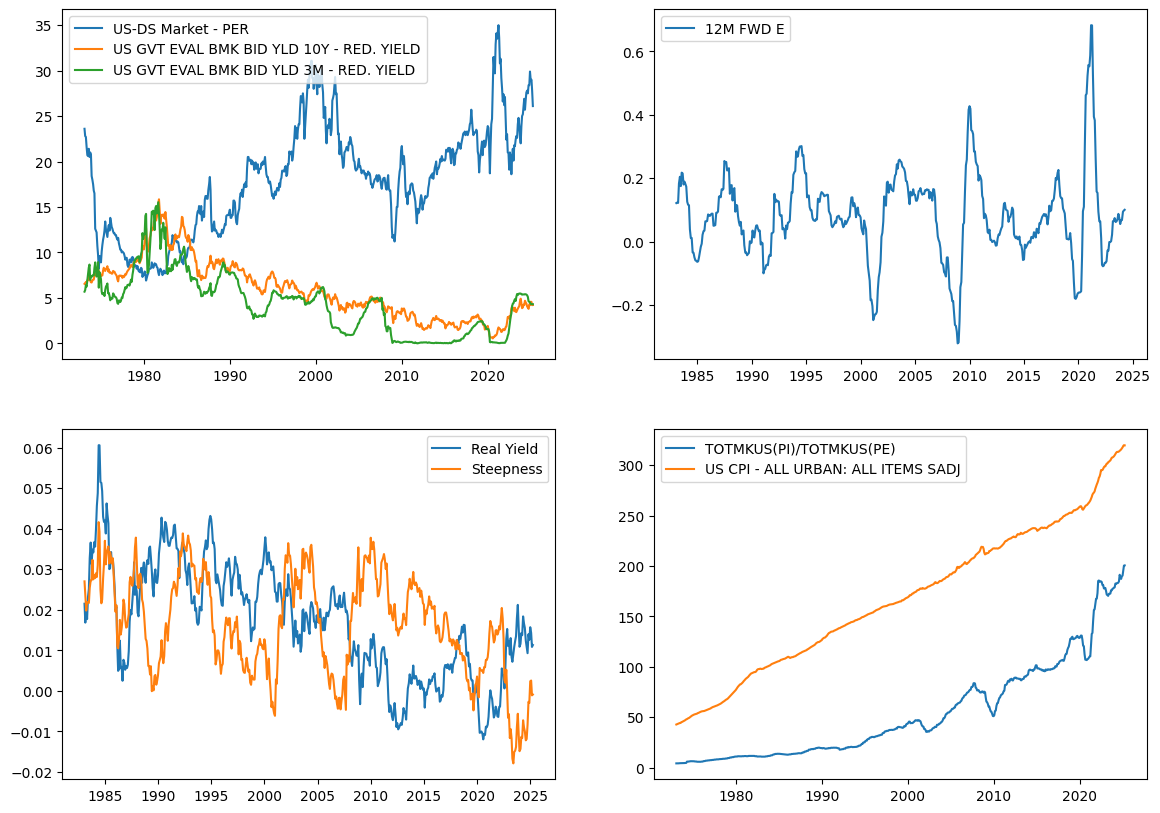

In [50]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)

plt.plot(df["US-DS Market - PER"],label="US-DS Market - PER")
plt.plot(df["US GVT EVAL BMK BID YLD 10Y - RED. YIELD"],label="US GVT EVAL BMK BID YLD 10Y - RED. YIELD")
plt.plot(df["US GVT EVAL BMK BID YLD 3M - RED. YIELD"],label="US GVT EVAL BMK BID YLD 3M - RED. YIELD")
plt.legend()
plt.subplot(2,2,2)

plt.plot(df["12M FWD E"],label="12M FWD E")
plt.legend()

plt.subplot(2,2,3)

plt.plot(df["Real Yield"],label="Real Yield")
plt.plot(df["Steepness"],label="Steepness")
plt.legend()


plt.subplot(2,2,4)

plt.plot(df["TOTMKUS(PI)/TOTMKUS(PE)"],label="TOTMKUS(PI)/TOTMKUS(PE)")
plt.plot(df["US CPI - ALL URBAN: ALL ITEMS SADJ"],label="US CPI - ALL URBAN: ALL ITEMS SADJ")
plt.legend()
plt.show()

In [58]:
df_station = pd.DataFrame(index=df.index)

diff_map = {
    "12M FWD E" : "FwdEarn_12M",
    "US-DS Market - PER": "PER_chg",
    "US GVT EVAL BMK BID YLD 10Y - RED. YIELD": "Yield_10Y_chg",
    "US GVT EVAL BMK BID YLD 3M - RED. YIELD": "Yield_3M_chg",
    "Real Yield": "RealYield_chg",
    "Steepness": "Steepness_chg",
    "TOTMKUS(PI)/TOTMKUS(PE)": "Earnings_chg",
    "US CPI - ALL URBAN: ALL ITEMS SADJ": "CPI_chg",
}
for old, new in diff_map.items():
    df_station[new] = df[old].diff()

df_station = df_station.dropna()

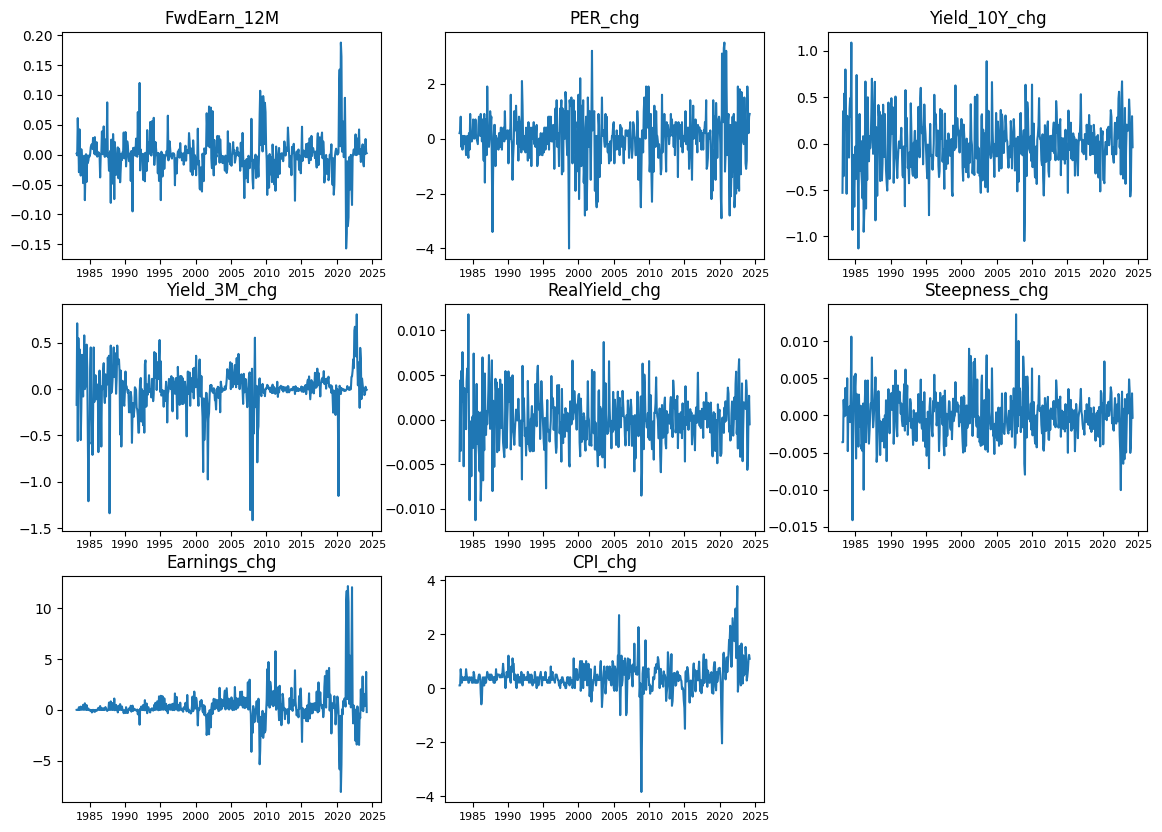

In [59]:
plt.figure(figsize=(14,10))

for i in range(len(df_station.keys())):
    plt.subplot(3,3,i+1)
    curr_key = df_station.keys()[i]
    plt.plot(df_station[curr_key])
    plt.title(curr_key)
    plt.xticks(fontsize=8)

plt.show()

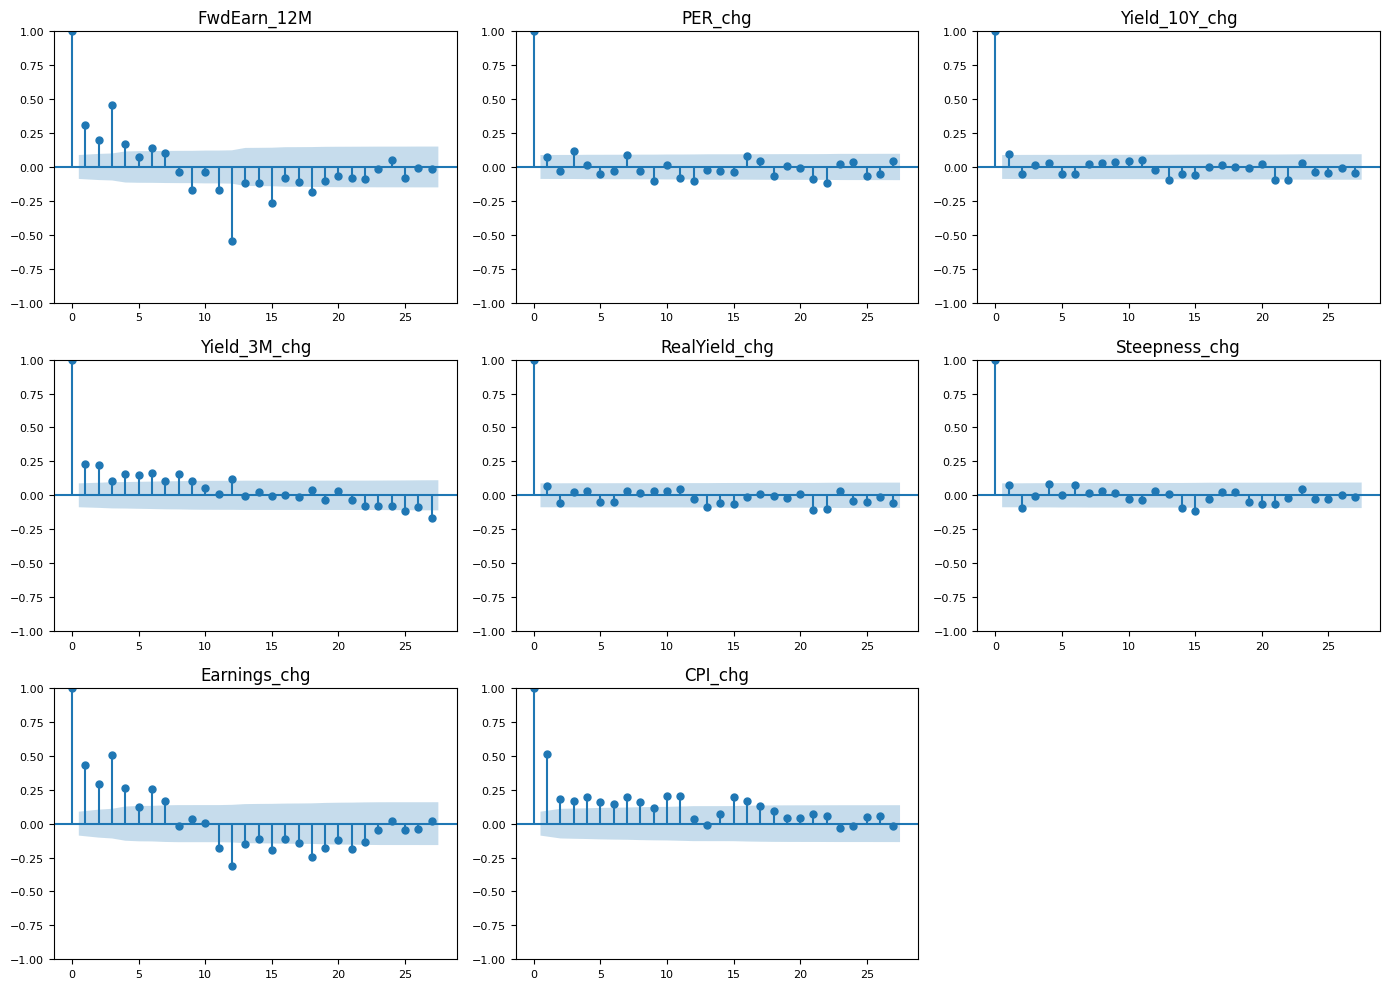

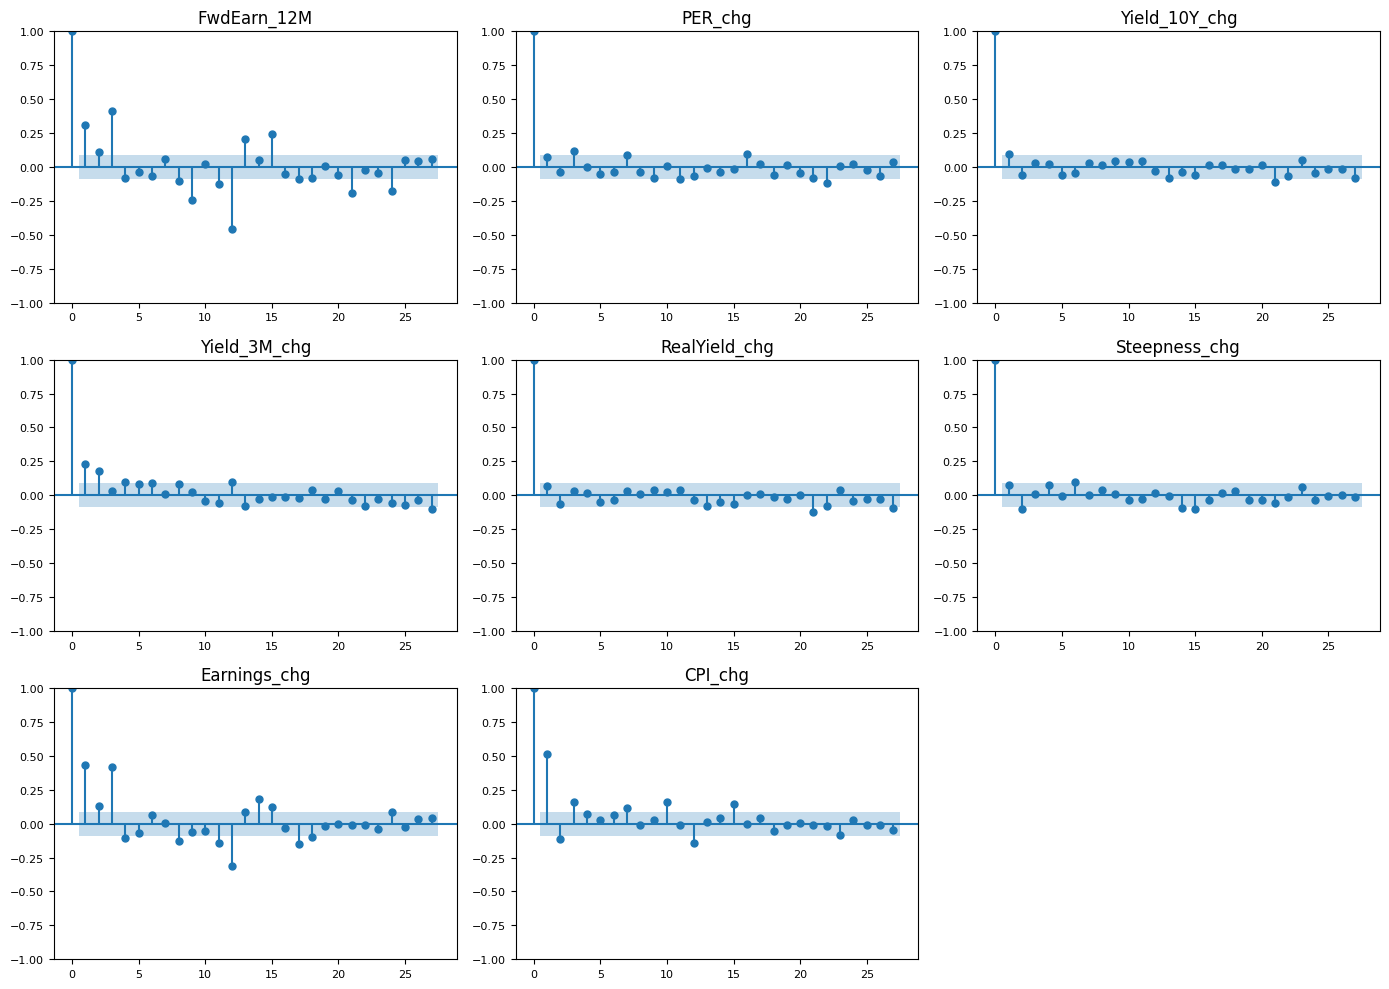

In [60]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
 
# ---- ACF ----
plt.figure(figsize=(14, 10))
for i in range(len(df_station.keys())):
    ax = plt.subplot(3, 3, i + 1)
    curr_key = df_station.keys()[i]
    plot_acf(df_station[curr_key].dropna(), ax=ax, alpha=0.05)   # alpha=0.05 -> 95% CI band
    ax.set_title(curr_key)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()
 
# ---- PACF ----
plt.figure(figsize=(14, 10))
for i in range(len(df_station.keys())):
    ax = plt.subplot(3, 3, i + 1)
    curr_key = df_station.keys()[i]
    plot_pacf(df_station[curr_key].dropna(), ax=ax, alpha=0.05, method="ywm")
    ax.set_title(curr_key)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()
 

C:\Users\trist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency BME will be used.
  self._init_dates(dates, freq)


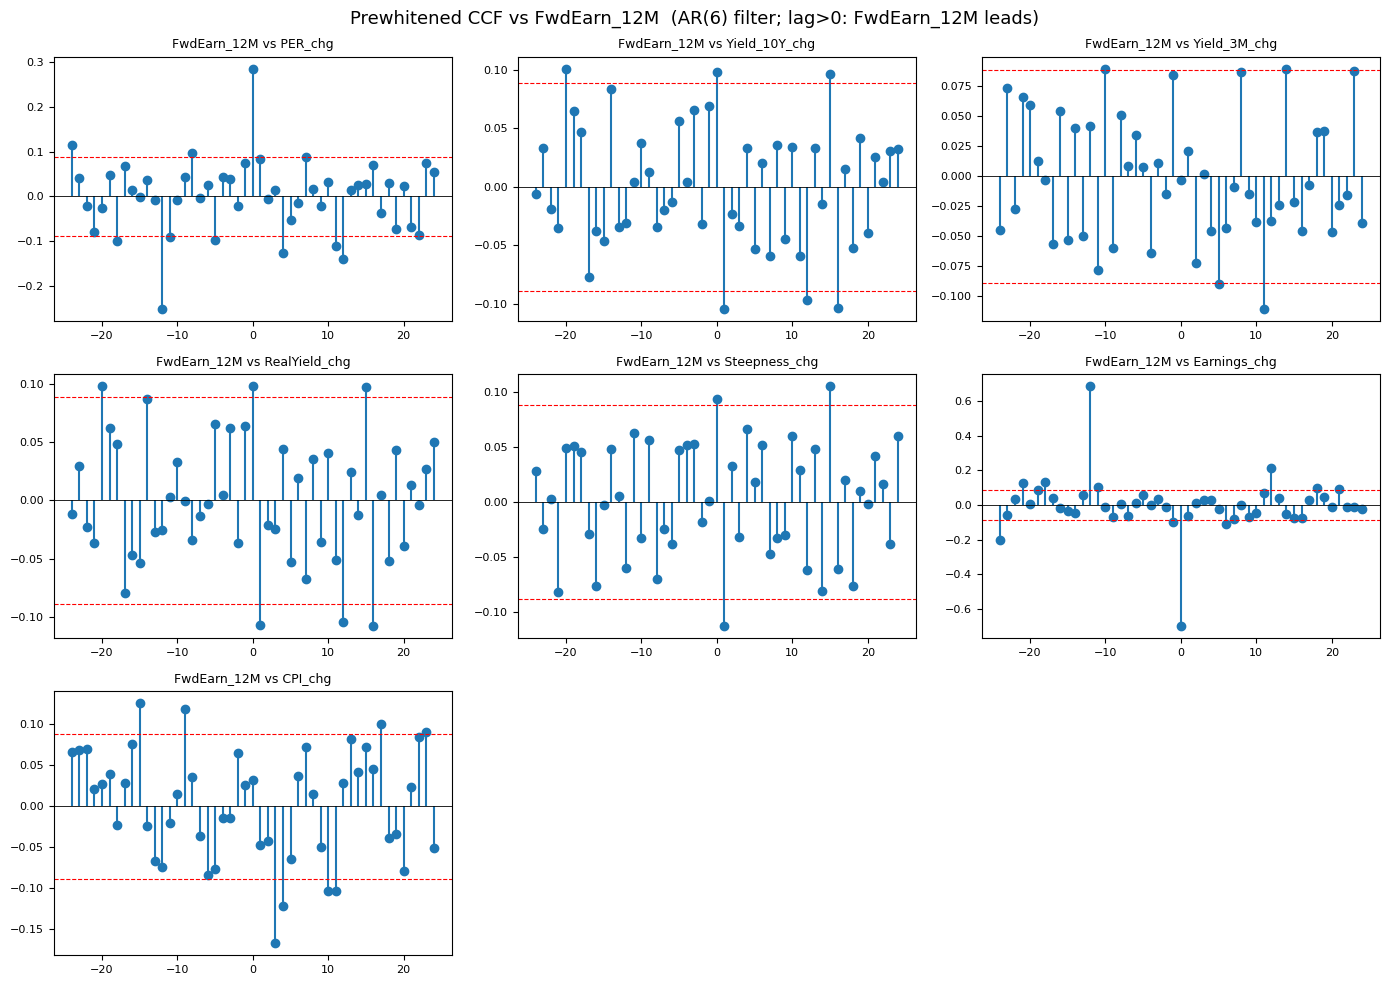

In [63]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import ccf

# Prewhitened cross-correlation vs a reference series.
# 1) fit AR(p) to REF        -> residuals are (approx) white
# 2) apply the SAME filter to every other series
# 3) CCF the whitened residuals -> true lead/lag spikes
REF    = "FwdEarn_12M"     # series we whiten
P      = 6                 # AR order for the reference
maxlag = 24

def ar_filter(series, params, p, ref_name):
    """residual_t = y_t - const - sum_k phi_k y_{t-k}, using REF's coefficients."""
    const = params.get("const", 0.0)
    phi = np.array([params[f"{ref_name}.L{k}"] for k in range(1, p + 1)])
    v = series.values
    res = np.full(len(v), np.nan)
    for t in range(p, len(v)):
        window = v[t-p:t][::-1]                 # y_{t-1}, ..., y_{t-p}
        res[t] = v[t] - const - np.dot(phi, window)
    return res

# fit AR(p) to the reference and get its whitened residuals
ref = df_station[REF]
fit = AutoReg(ref, lags=P, old_names=False).fit()
ex = fit.resid.values
ex = (ex - np.nanmean(ex)) / np.nanstd(ex)

cols = [c for c in df_station.keys() if c != REF]
plt.figure(figsize=(14, 10))
for i, c in enumerate(cols):
    ax = plt.subplot(3, 3, i + 1)

    yf = ar_filter(df_station[c], fit.params, P, REF)[P:]    # filter other series
    yf = (yf - np.nanmean(yf)) / np.nanstd(yf)
    n = min(len(ex), len(yf))
    a, b = ex[-n:], yf[-n:]

    fwd = ccf(a, b, adjusted=False)[:maxlag + 1]            # REF leads (k>=0)
    bwd = ccf(b, a, adjusted=False)[:maxlag + 1]            # other leads
    lags = np.arange(-maxlag, maxlag + 1)
    vals = np.concatenate([bwd[1:][::-1], fwd])

    ax.stem(lags, vals, basefmt=" ")
    ci = 1.96 / np.sqrt(n)
    ax.axhline( ci, color="r", ls="--", lw=0.8)
    ax.axhline(-ci, color="r", ls="--", lw=0.8)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{REF} vs {c}", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(f"Prewhitened CCF vs {REF}  (AR({P}) filter; lag>0: {REF} leads)", fontsize=13)
plt.tight_layout()
plt.show()